# Iris — exploratory plots

Daily notebook — small experiment, fully reproducible (seed pinned below).

Just looking at the data today — distributions per feature and how the species separate.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)

from sklearn.datasets import load_iris


## Data

In [ ]:
SEED = 1351
X, y = load_iris(return_X_y=True, as_frame=True)
df = X.copy(); df["species"] = y
print(df.describe().round(2).to_string())


       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  species
count             150.00            150.00             150.00            150.00   150.00
mean                5.84              3.06               3.76              1.20     1.00
std                 0.83              0.44               1.77              0.76     0.82
min                 4.30              2.00               1.00              0.10     0.00
25%                 5.10              2.80               1.60              0.30     0.00
50%                 5.80              3.00               4.35              1.30     1.00
75%                 6.40              3.30               5.10              1.80     2.00
max                 7.90              4.40               6.90              2.50     2.00


## Feature histograms

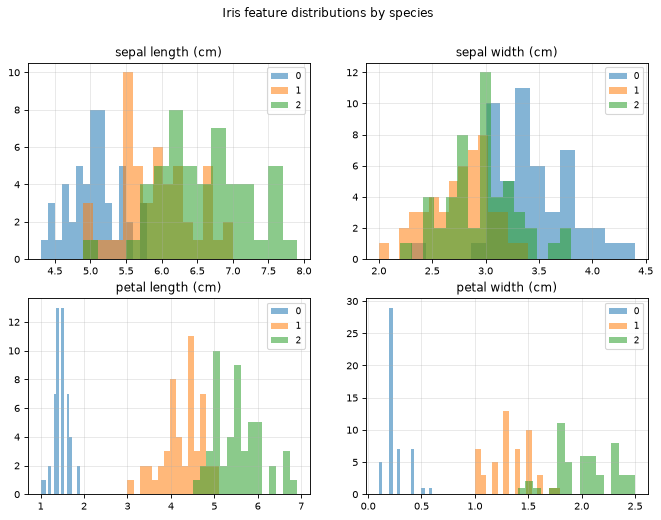

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flat, X.columns):
    for i in range(3):
        ax.hist(df.loc[df["species"] == i, col], bins=15, alpha=0.55, label=str(i))
    ax.set_title(col); ax.legend(fontsize=8)
fig.suptitle("Iris feature distributions by species")


## Correlation

                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)               1.00             -0.12               0.87              0.82
sepal width (cm)               -0.12              1.00              -0.43             -0.37
petal length (cm)               0.87             -0.43               1.00              0.96
petal width (cm)                0.82             -0.37               0.96              1.00


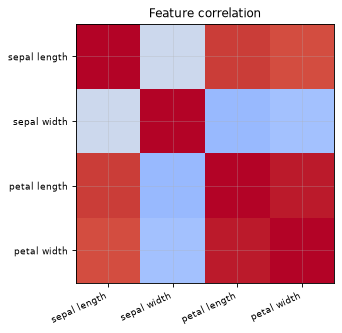

In [ ]:

corr = X.corr().round(2)
print(corr.to_string())
fig, ax = plt.subplots()
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([c.replace(" (cm)", "") for c in X.columns], rotation=25, ha="right", fontsize=8)
ax.set_yticklabels([c.replace(" (cm)", "") for c in X.columns], fontsize=8)
ax.set_title("Feature correlation")


## Notes

- Petal length/width are nearly collinear — one would almost do.
- Sepal width is the odd one out, weakly correlated with the rest.